Figuras:
1. Observado vs predicciones 2024-2026 + boxplot residuales
2. Ciclo anual + distribución de frecuencia
3. Heatmaps de predicciones
4. Validación con Collahuasi + Sentinel-1 (pendiente)
5. Comparación con datos hidrometeorológicos (pendiente)

In [51]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from pypalettes import load_cmap
import numpy as np
import pandas as pd
import seaborn as sns

from v2_data_preparation import load_and_prepare_data, process_insitu, slice_by_dates

In [52]:
observed_fp1 = '../data/processed/in-situ/SDH1_daily-insitu-data.csv'
observed_fp2 = '../data/processed/in-situ/SDH2_daily-insitu-data.csv'

modeled_fp1 = '../outputs/predictions/SDH1_2000-2026_noAnchored_difRolling.csv'
modeled_fp2 = '../outputs/predictions/SDH2_2000-2026_noAnchored_difRolling.csv'

In [53]:
sdh1_observed = process_insitu(
    filepath=observed_fp1,
    start_date='2024-05-24',
    end_date='2026-05-14',
    cols_to_keep=['SDH1PS01_gw-depth_m'],
    outlier_threshold=3
)
sdh2_observed = process_insitu(
    filepath=observed_fp2,
    start_date='2024-05-24',
    end_date='2026-05-14',
    cols_to_keep=['SDH2PP01_gw-depth_m'],
    outlier_threshold=3
)

In [54]:
sdh1_observed = sdh1_observed.rename(columns={'SDH1PS01_gw-depth_m':'observed'})
sdh2_observed = sdh2_observed.rename(columns={'SDH2PP01_gw-depth_m':'observed'})

In [55]:
sdh1_modeled = (
    load_and_prepare_data(modeled_fp1)
    .pipe(slice_by_dates, startDate='2000-03', endDate='2026-05-14')
)
sdh2_modeled = (
    load_and_prepare_data(modeled_fp2)
    .pipe(slice_by_dates, startDate='2000-03', endDate='2026-05-14')
)

In [56]:
sdh1_observed = sdh1_observed * -1
sdh2_observed = sdh2_observed * -1
sdh1_modeled = sdh1_modeled * -1
sdh2_modeled = sdh2_modeled * -1

#### 1. Observado vs predicciones 2024-2026 + boxplot residuales
Datos:
- Valores observados en ambos pozos desde jun 2024 hasta presente
- Predicciones de los modelos en el mismo periodo
- Residuales en periodo de prueba, divididos por estación

Pendientes:
- Unir gráficas en una figura
- Uniformizar paleta de colores entre figuras (dar colores a cada sitio)
- Correr modelo con datos no anclados (y sumar aleatoriedad)
- Corregir offset en pozo SDH1PS01 a contar de mayo 2026
- Evaluar cómo presentar profundidades

In [57]:
sdh1_modeled_present = slice_by_dates(sdh1_modeled, startDate='2024-05-24')
sdh2_modeled_present = slice_by_dates(sdh2_modeled, startDate='2024-05-24')

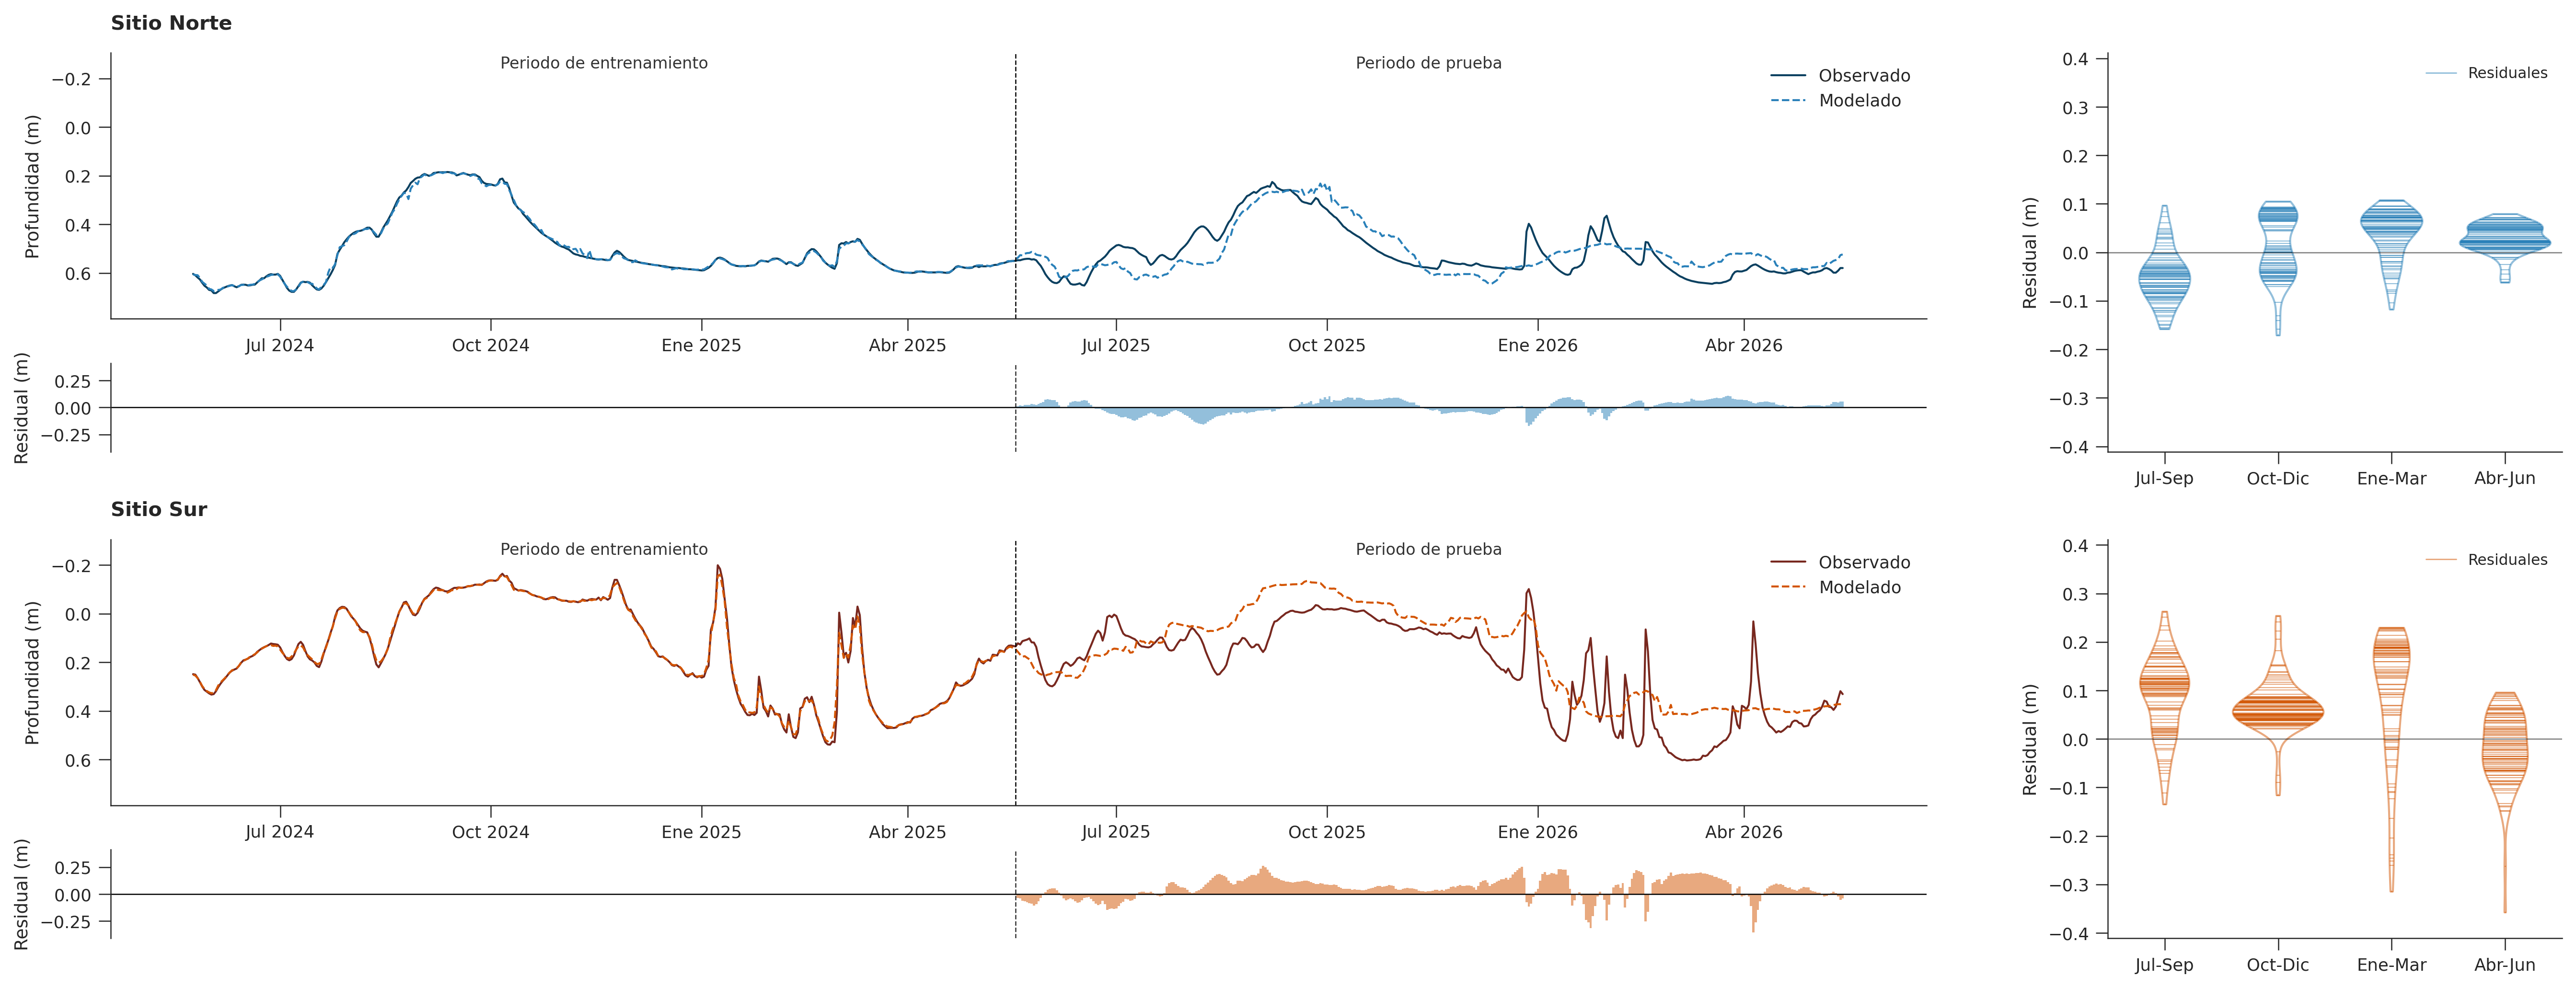

In [71]:
# Set global seaborn styling for scientific publication
sns.set_theme(style="ticks")
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,
        "figure.titlesize": 11,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
    }
)

# -------------------------------------------------------------------------
# 1. Configuration & color palettes
# Consistent color system: SDH1 (Blue hue family) | SDH2 (Vermilion hue family)
# -------------------------------------------------------------------------
SITE_COLORS = {
    "sdh1": {
        "observed": "#0b4060",
        "modeled": "#2980b9",
        "residual": "#2980b9",
        "violin": "#2980b980",
    },
    "sdh2": {
        "observed": "#78281f",
        "modeled": "#d35400",
        "residual": "#d35400",
        "violin": "#d3540080",
    },
}

# Training/test split date
SPLIT_DATE = pd.Timestamp("2025-05-18")


# -------------------------------------------------------------------------
# 2. Helper Functions
# -------------------------------------------------------------------------
def assign_season(dates: pd.DatetimeIndex) -> list:
    """Assign meteorological season based on datetime index."""
    seasons = []
    for month in dates.month:
        if month in [1, 2, 3]:
            seasons.append("Ene-Mar")
        elif month in [4, 5, 6]:
            seasons.append("Abr-Jun")
        elif month in [7, 8, 9]:
            seasons.append("Jul-Sep")
        else:
            seasons.append("Oct-Dic")
    return seasons


def add_period_brackets(
    ax,
    start_date: pd.Timestamp,
    split_date: pd.Timestamp,
    end_date: pd.Timestamp,
):
    """Draw horizontal indicator lines for training and testing periods."""
    # Blended transform: x in data coordinates (dates), y in axes coordinates [0, 1]
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    
    y_text = 0.93

    # Training period bar
    train_mid = start_date + (split_date - start_date) / 2
    ax.text(
        train_mid,
        y_text,
        "Periodo de entrenamiento",
        transform=trans,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#333333",
    )

    # Test period bar
    test_mid = split_date + (end_date - split_date) / 2
    ax.text(
        test_mid,
        y_text,
        "Periodo de prueba",
        transform=trans,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#333333",
    )

    # Vertical boundary line
    ax.axvline(
        split_date, color="black", linestyle="--", linewidth=0.6, alpha=1
    )

SPANISH_MONTHS = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

def format_date_es(x, pos=None):
    """Format matplotlib date numbers as 'Mes AAAA' in Spanish."""
    date = mdates.num2date(x)
    month_name = SPANISH_MONTHS[date.month]
    return f"{month_name} {date.year}"


# -------------------------------------------------------------------------
# 3. Residuals & seasonal data preparation
# -------------------------------------------------------------------------
# SDH1 test residuals
sdh1_test_obs = sdh1_observed.loc[SPLIT_DATE:]
sdh1_test_mod = sdh1_modeled_present.loc[SPLIT_DATE:]
sdh1_res = pd.DataFrame(
    {"residual": sdh1_test_obs["observed"] - sdh1_test_mod["predicted"]},
    index=sdh1_test_obs.index,
)
sdh1_res["season"] = assign_season(sdh1_res.index)

# SDH2 test residuals
sdh2_test_obs = sdh2_observed.loc[SPLIT_DATE:]
sdh2_test_mod = sdh2_modeled_present.loc[SPLIT_DATE:]
sdh2_res = pd.DataFrame(
    {"residual": sdh2_test_obs["observed"] - sdh2_test_mod["predicted"]},
    index=sdh2_test_obs.index,
)
sdh2_res["season"] = assign_season(sdh2_res.index)

season_order = ["Jul-Sep", "Oct-Dic", "Ene-Mar", "Abr-Jun"]
sdh1_res["season"] = pd.Categorical(
    sdh1_res["season"], categories=season_order, ordered=True
)
sdh2_res["season"] = pd.Categorical(
    sdh2_res["season"], categories=season_order, ordered=True
)

# Unified limits across sites for direct comparability
y_min_depth = min(
    sdh1_observed["observed"].min(),
    sdh2_observed["observed"].min(),
    sdh1_modeled_present["predicted"].min(),
    sdh1_modeled_present["predicted"].min(),
)
y_max_depth = max(
    sdh1_observed["observed"].max(),
    sdh2_observed["observed"].max(),
    sdh1_modeled_present["predicted"].max(),
    sdh2_modeled_present["predicted"].max(),
)
depth_margin = (y_max_depth - y_min_depth) * 0.12

max_residual = (
    max(sdh1_res["residual"].abs().max(), sdh2_res["residual"].abs().max())
    * 1.15
)

# -------------------------------------------------------------------------
# 4. Figure Layout & Plotting
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(22, 8), dpi=300)
outer_grid = fig.add_gridspec(
    2, 2, width_ratios=[3.2, 0.8], wspace=0.16, hspace=0.22
)

sites = [
    {
        "name": "Sitio Norte",
        "key": "sdh1",
        "obs": sdh1_observed,
        "mod": sdh1_modeled_present,
        "res": sdh1_res,
        "row": 0,
    },
    {
        "name": "Sitio Sur",
        "key": "sdh2",
        "obs": sdh2_observed,
        "mod": sdh2_modeled_present,
        "res": sdh2_res,
        "row": 1,
    },
]

for s in sites:
    k = s["key"]
    row_idx = s["row"]

    # Subgridspec for left column: [Time series (3.2), Residual bar strip (1.0)]
    ts_subgrid = outer_grid[row_idx, 0].subgridspec(
        2, 1, height_ratios=[3.0, 1.0], hspace=0.25
    )
    ax_depth = fig.add_subplot(ts_subgrid[0])
    ax_res = fig.add_subplot(ts_subgrid[1], sharex=ax_depth)

    # Subplot for right column: Seasonal violin plots
    ax_violin = fig.add_subplot(outer_grid[row_idx, 1])

    # --- A. Depth Time Series ---
    ax_depth.plot(
        s["obs"].index,
        s["obs"]["observed"],
        label="Observado",
        color=SITE_COLORS[k]["observed"],
        linewidth=1,
    )
    ax_depth.plot(
        s["mod"].index,
        s["mod"]["predicted"],
        label="Modelado",
        color=SITE_COLORS[k]["modeled"],
        linestyle="--",
        linewidth=1,
    )

    ax_depth.set_ylim(y_max_depth + depth_margin, y_min_depth - depth_margin)
    ax_depth.set_ylabel("Profundidad (m)")
    ax_depth.set_title(s["name"], loc="left", fontweight="bold", pad=12)
    ax_depth.legend(loc="upper right", frameon=False, framealpha=0.9)
    # Set Spanish month-year formatting
    ax_depth.xaxis.set_major_formatter(FuncFormatter(format_date_es))
    #ax_depth.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax_depth.tick_params(bottom=True, labelbottom=True)

    # Indicator horizontal line for train/test periods
    add_period_brackets(
        ax_depth, s["obs"].index[0], SPLIT_DATE, s["obs"].index[-1]
    )

    # --- B. Test Period Residuals (Bars from x-axis) ---
    ax_res.bar(
        s["res"].index,
        s["res"]["residual"],
        width=1,
        color=SITE_COLORS[k]["residual"],
        edgecolor= None,
        linewidth=0,
        alpha=0.5,
        align="center",
    )
    ax_res.axhline(0, color="black", linestyle="-", linewidth=0.6)
    ax_res.axvline(
        SPLIT_DATE, color="black", linestyle="--", linewidth=0.6, alpha=0.8
    )
    ax_res.set_ylim(-max_residual, max_residual)
    ax_res.set_ylabel("Residual (m)")
    #ax_res.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax_res.tick_params(bottom=False, labelbottom=False)
    
    if row_idx == 1:
        ax_res.set_xlabel("")

    # --- C. Seasonal Violin Plots ---
    sns.violinplot(
        data=s["res"],
        x="season",
        y="residual",
        ax=ax_violin,
        color=SITE_COLORS[k]["violin"],
        fill=False,
        inner='stick',
        linewidth=1,
        cut=0,
    )

    legend_elements = [
    Line2D([0], [0], color=SITE_COLORS[k]["violin"], linestyle="-", lw=0.7, label="Residuales")
    ]

    ax_violin.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=False,
    framealpha=0.9,
    edgecolor="#dddddd",
    fontsize=7.5
    )

    ax_violin.axhline(0, color="black", linestyle="-", linewidth=0.6, alpha=0.5)
    ax_violin.set_ylim(-max_residual, max_residual)
    ax_violin.set_ylabel("Residual (m)")

    if row_idx == 1:
        ax_violin.set_xlabel("")
    else:
        ax_violin.set_xlabel("")

    sns.despine(ax=ax_depth, top=True, right=True, bottom=False)
    sns.despine(ax=ax_res, top=True, right=True, bottom=True)
    sns.despine(ax=ax_violin, top=True, right=True)
    plt.setp(ax_res.get_xticklabels(), visible=False)

plt.show()
#plt.savefig('../outputs/figures/fig3.png', transparent=True)

#### 2. Ciclo anual + distribución de frecuencia
Datos:
- Valores observados en ambos pozos desde jun 2024 hasta presente
- Predicciones de los modelos entre 2000 y 2024

Pendientes:
- Asegurar colores consistentes
- Editar etiquetas

In [59]:
sdh1_modeled_2000_2024 = slice_by_dates(sdh1_modeled, endDate='2024-05-24')
sdh2_modeled_2000_2024 = slice_by_dates(sdh2_modeled, endDate='2024-05-24')

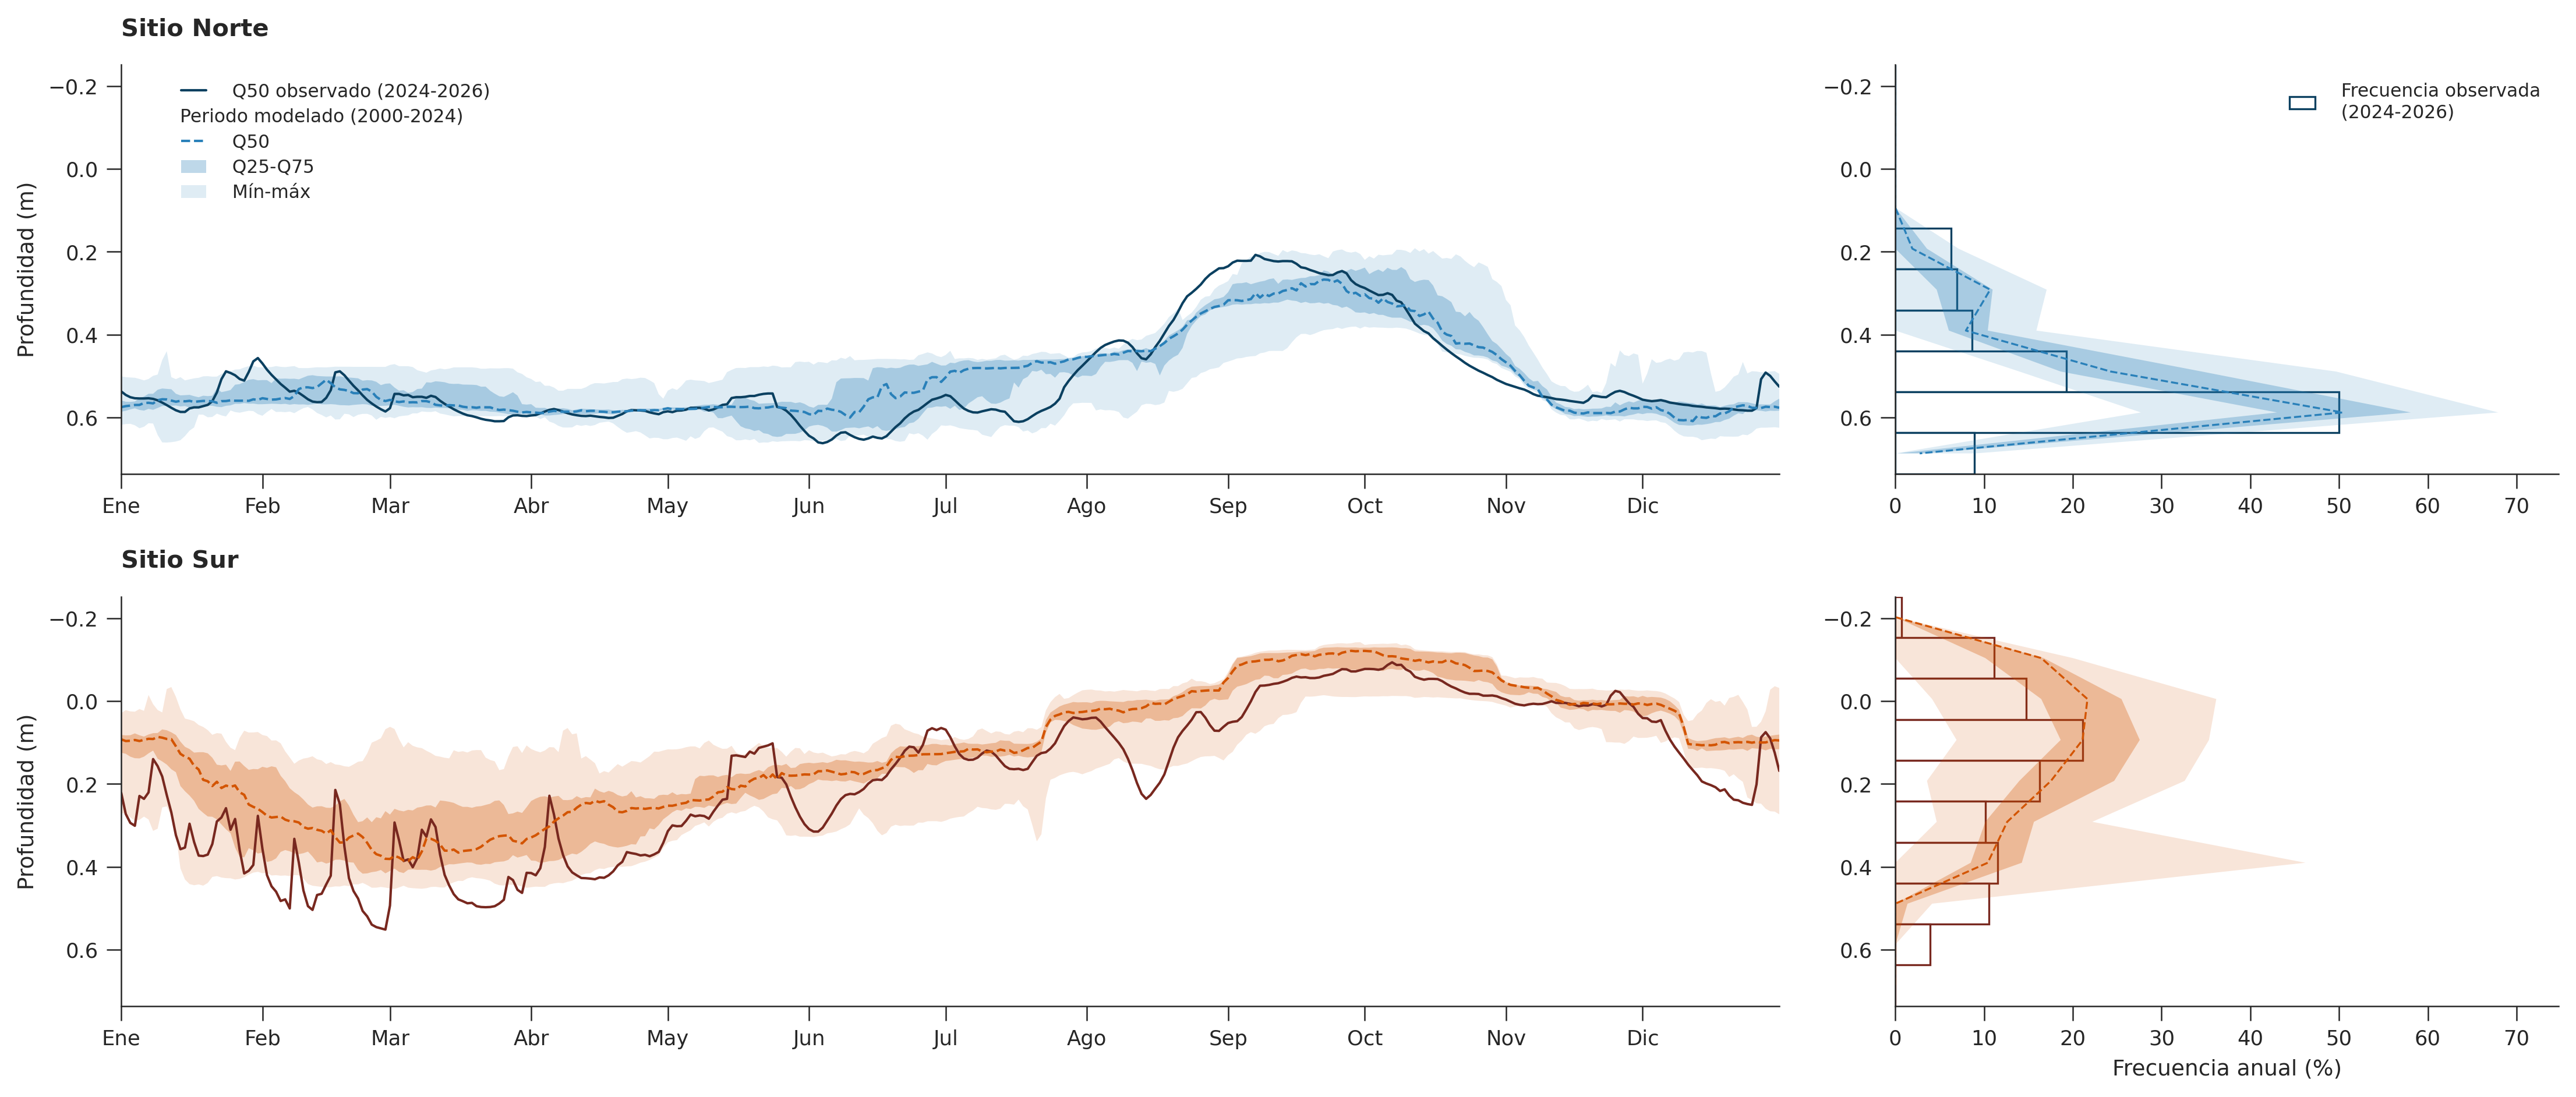

In [70]:
# Set global styling for scientific publication
sns.set_theme(style="ticks")
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,
        "figure.titlesize": 11,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
    }
)

# -------------------------------------------------------------------------
# 1. Configuration & Color Palettes
# SDH1 (Blue family) | SDH2 (Vermilion family)
# -------------------------------------------------------------------------
SITE_COLORS = {
    "sdh1": {
        "observed": "#0b4060",
        "modeled": "#2980b9",
    },
    "sdh2": {
        "observed": "#78281f",
        "modeled": "#d35400",
    },
}

NUMBER_OF_BINS = 10


# -------------------------------------------------------------------------
# 2. Helper Functions
# -------------------------------------------------------------------------
def clean_annual_series(df: pd.DataFrame) -> pd.Series:
    """Drop NaN values and remove leap day (DOY 366) to standardize to 365 days."""
    s = df.iloc[:, 0].dropna()
    return s[s.index.dayofyear <= 365]


def compute_annual_cycle_stats(series: pd.Series) -> pd.DataFrame:
    """Calculate daily DOY percentiles and extrema across years."""
    df_doy = pd.DataFrame({"depth": series, "doy": series.index.dayofyear})
    return (
        df_doy.groupby("doy")["depth"]
        .agg(
            mean='mean',
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            v_min="min",
            v_max="max",
        )
        .reindex(range(1, 366))
    )


# def compute_modeled_pdf_stats(series: pd.Series, bin_edges: np.ndarray):
#     """Compute annual frequency distribution percentiles across years for depth bins."""
#     annual_densities = []
#     for _, year_group in series.groupby(series.index.year):
#         if len(year_group) > 30:
#             counts, _ = np.histogram(
#                 year_group.values, bins=bin_edges, density=True
#             )
#             annual_densities.append(counts)

#     dens_matrix = np.array(annual_densities)
#     return (
#         np.min(dens_matrix, axis=0),
#         np.percentile(dens_matrix, 25, axis=0),
#         np.median(dens_matrix, axis=0),
#         np.percentile(dens_matrix, 75, axis=0),
#         np.max(dens_matrix, axis=0),
#     )
def compute_modeled_pdf_stats(series: pd.Series, bin_edges: np.ndarray):
    """Compute annual percentage distribution percentiles across years for depth bins."""
    annual_percentages = []
    for _, year_group in series.groupby(series.index.year):
        valid_vals = year_group.dropna().values
        if len(valid_vals) > 30:
            counts, _ = np.histogram(valid_vals, bins=bin_edges)
            # Relative frequency in percent (sums to 100% per year)
            percentages = (counts / len(valid_vals)) * 100.0
            annual_percentages.append(percentages)

    pct_matrix = np.array(annual_percentages)
    return (
        np.min(pct_matrix, axis=0),
        np.percentile(pct_matrix, 25, axis=0),
        np.median(pct_matrix, axis=0),
        np.percentile(pct_matrix, 75, axis=0),
        np.max(pct_matrix, axis=0),
    )

# -------------------------------------------------------------------------
# 3. Data Preprocessing & Global Scale Definition
# -------------------------------------------------------------------------

series_mod_sdh1 = clean_annual_series(
    sdh1_modeled_2000_2024
)
series_obs_sdh1 = clean_annual_series(
    sdh1_observed
)
series_mod_sdh2 = clean_annual_series(
    sdh2_modeled_2000_2024
)
series_obs_sdh2 = clean_annual_series(
    sdh2_observed
)

# Unified depth limits across all sites and panels
all_depth_values = np.concatenate(
    [
    series_mod_sdh1.values,
    series_obs_sdh1.values,
    series_mod_sdh2.values,
    series_obs_sdh2.values,
    ]
)
depth_pad = (all_depth_values.max() - all_depth_values.min()) * 0.06
depth_min = all_depth_values.min() - depth_pad
depth_max = all_depth_values.max() + depth_pad

# Bin structure for horizontal frequency distributions
bin_edges = np.linspace(depth_min, depth_max, NUMBER_OF_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# Calendar month ticks for annual cycle DOY (non-leap year)
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]

# -------------------------------------------------------------------------
# 5. Figure Setup & Rendering
# -------------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 7),
    sharey=True,
    gridspec_kw={"width_ratios": [3.0, 1.2], "wspace": 0.1, "hspace": 0.3},
    dpi=300,
)

sites_config = [
    {
        "key": "sdh1",
        "name": "Sitio Norte",
        "mod_series": series_mod_sdh1,
        "obs_series": series_obs_sdh1,
        "ax_cycle": axes[0, 0],
        "ax_dist": axes[0, 1],
        "row_idx": 0,
    },
    {
        "key": "sdh2",
        "name": "Sitio Sur",
        "mod_series": series_mod_sdh2,
        "obs_series": series_obs_sdh2,
        "ax_cycle": axes[1, 0],
        "ax_dist": axes[1, 1],
        "row_idx": 1,
    },
]

max_density_observed = 0.0

for s in sites_config:
    k = s["key"]
    c_mod = SITE_COLORS[k]["modeled"]
    c_obs = SITE_COLORS[k]["observed"]
    ax_cycle = s["ax_cycle"]
    ax_dist = s["ax_dist"]

    # --- A. Annual Cycle (Left Panel) ---
    stats_mod = compute_annual_cycle_stats(s["mod_series"])
    stats_obs = compute_annual_cycle_stats(s["obs_series"])

    # Median trajectories
    ax_cycle.plot(
            stats_obs.index,
            stats_obs["median"],
            color=c_obs,
            linestyle="-",
            linewidth=1,
            label="Mediana 2024-2026 (observada)",
        )
    ax_cycle.plot(
        stats_mod.index,
        stats_mod["median"],
        color=c_mod,
        linestyle="--",
        linewidth=1,
        label="Mediana 2000-2024 (modelada)",
    )
    
    # Modeled envelopes: Min-Max and Q25-Q75
    ax_cycle.fill_between(
        stats_mod.index,
        stats_mod["q25"],
        stats_mod["q75"],
        color=c_mod,
        alpha=0.30,
        edgecolor="none",
        label="q25-q75 2000-2024",
    )
    ax_cycle.fill_between(
        stats_mod.index,
        stats_mod["v_min"],
        stats_mod["v_max"],
        color=c_mod,
        alpha=0.15,
        edgecolor="none",
        label="Mín-máx 2000-2024",
    )
    
    ax_cycle.set_title(s["name"], loc="left", fontweight="bold", pad=12)
    #ax_cycle.set_title(f"Ciclo anual — {s['name']}", loc="left")
    ax_cycle.set_ylabel("Profundidad (m)")
    ax_cycle.set_xlim(1, 365)
    ax_cycle.set_xticks(month_starts)
    ax_cycle.set_xticklabels(month_labels)
    #ax_cycle.grid(True, linestyle="--", alpha=0.3, linewidth=0.5)

    if s["row_idx"] == 1:
        ax_cycle.set_xlabel("")
    else:
        ax_cycle.set_xlabel("")

    # --- B. Frequency Distribution (Right Panel) ---
    # Observed horizontal histogram bars
    # obs_density, _ = np.histogram(
    #     s["obs_series"].values, bins=bin_edges, density=True
    # )

    # Observed frequency percentage (sums to 100%)
    obs_vals = s["obs_series"].dropna().values
    counts_obs, _ = np.histogram(obs_vals, bins=bin_edges)
    obs_percentage = (counts_obs / len(obs_vals)) * 100.0

    ax_dist.barh(
        bin_centers,
        obs_percentage,
        height=bin_width,
        facecolor='white',
        alpha=1,
        edgecolor=c_obs,
        linewidth=0.8,
        label="Frecuencia 2024-2026",
    )

    # Modeled interannual variability envelopes
    p_min, p25, med, p75, p_max = compute_modeled_pdf_stats(
        s["mod_series"], bin_edges
    )

    ax_dist.fill_betweenx(
        bin_centers,
        p_min,
        p_max,
        color=c_mod,
        alpha=0.15,
        edgecolor="none",
        label="Frec. 2000-2024 (mín-máx)",
    )
    ax_dist.fill_betweenx(
        bin_centers,
        p25,
        p75,
        color=c_mod,
        alpha=0.30,
        edgecolor="none",
        label="Frec. 2000-2024 (q25-q75)",
    )
    ax_dist.plot(
        med,
        bin_centers,
        color=c_mod,
        linestyle="--",
        linewidth=0.8,
        label="Frec. 2000-2024 (q50)",
    )
    # ax_dist.barh(
    #     bin_centers,
    #     med,
    #     height=bin_width,
    #     facecolor='white',
    #     alpha=1,
    #     edgecolor=c_mod,
    #     linewidth=0.8,
    #     label="Frecuencia 2024-2026",
    # )

    #ax_dist.set_title(f"Distribución de frecuencia — {s['name']}", loc="left")
    #ax_dist.grid(True, linestyle="--", alpha=0.3, linewidth=0.5)
    ax_dist.tick_params(labelleft=True)


    if s["row_idx"] == 1:
        ax_dist.set_xlabel("Frecuencia anual (%)")
    else:
        ax_dist.set_xlabel("")

    # Track maximum density for consistent horizontal scaling
    local_max = max(obs_percentage.max(), p_max.max())
    if local_max > max_density_observed:
        max_density_observed = local_max

    # Spine formatting
    sns.despine(ax=ax_cycle, top=True, right=True)
    sns.despine(ax=ax_dist, top=True, right=True)

# -------------------------------------------------------------------------
# 6. Global Scale Alignment & Inverted Y-Axis
# Invert Y-axis so groundwater depth increases downwards (depth_max at bottom)
# -------------------------------------------------------------------------
axes[0, 0].set_ylim(depth_max, depth_min)

# Standardize horizontal limits for density panels
density_x_limit = max_density_observed * 1.10
axes[0, 1].set_xlim(0, density_x_limit)
axes[1, 1].set_xlim(0, density_x_limit)

# Colores de referencia para las leyendas (usando el sitio superior SDH1)
c_mod_ref = SITE_COLORS["sdh1"]["modeled"]
c_obs_ref = SITE_COLORS["sdh1"]["observed"]

# --- Leyenda para el Ciclo Anual (axes[0, 0]) ---
cycle_legend_elements = [
    # Subsección observado
    # Line2D(
    #     [],
    #     [], 
    #     color="none", 
    #     label="Periodo observado (2000-2024)"
    # ),
    Line2D(
        [0],
        [0],
        color=c_obs_ref,
        linestyle="-",
        linewidth=1,
        label="  Q50 observado (2024-2026)",
    ),
    # Patch(
    #     facecolor="none",
    #     edgecolor=c_obs_ref,
    #     linewidth=0.8,
    #     label="  Frecuencia",
    # ),
    # Subsección modelado
    Line2D(
        [],
        [], 
        color="none", 
        label="Periodo modelado (2000-2024)"
    ),
    Line2D(
        [0],
        [0],
        color=c_mod_ref,
        linestyle="--",
        linewidth=1,
        label="  Q50",
    ),
    Patch(
        facecolor=c_mod_ref,
        alpha=0.30,
        edgecolor="none",
        label="  Q25-Q75",
    ),
    Patch(
        facecolor=c_mod_ref,
        alpha=0.15,
        edgecolor="none",
        label="  Mín-máx",
    ),
]

leg_cycle = axes[0, 0].legend(
    handles=cycle_legend_elements,
    loc="upper left",
    bbox_to_anchor=(0.025, 1.0),
    frameon=False,
    framealpha=0.92,
    edgecolor="#dddddd",
    fontsize=7.5,
    handlelength=1.4,
    labelspacing=0.4,
    borderpad=0.5,
)

title_text1 = leg_cycle.get_texts()[1]
title_text1.set_position((-70, 0))
# title_text0 = leg_cycle.get_texts()[0]
# title_text0.set_position((-70, 0))
# title_text3 = leg_cycle.get_texts()[3]
# title_text3.set_position((-70, 0))

# --- Leyenda para la Distribución de Frecuencia (axes[0, 1]) ---
dist_legend_elements = [
    # Subsección observado
    Patch(
        facecolor="none",
        edgecolor=c_obs_ref,
        linewidth=0.8,
        label="  Frecuencia observada\n  (2024-2026)",
    ),
    # # Subsección modelado
    # Line2D(
    #     [], 
    #     [], 
    #     color="none", 
    #     label="Periodo modelado (2000-2024)"),
    # Line2D(
    #     [0],
    #     [0],
    #     color=c_mod_ref,
    #     linestyle="--",
    #     linewidth=1,
    #     label="  Q50",
    # ),
    # Patch(
    #     facecolor=c_mod_ref,
    #     alpha=0.30,
    #     edgecolor="none",
    #     label="  Q25-Q75",
    # ),
    # Patch(
    #     facecolor=c_mod_ref,
    #     alpha=0.15,
    #     edgecolor="none",
    #     label="  Mín-máx",
    # ),
]

leg_dist = axes[0, 1].legend(
    handles=dist_legend_elements,
    loc="upper right",
    frameon=False,
    framealpha=0.92,
    edgecolor="#dddddd",
    fontsize=7.5,
    handlelength=1.4,
    labelspacing=0.4,
    borderpad=0.5,
)

# title_text = leg_dist.get_texts()[1]
# title_text.set_position((-70, 0))

plt.show()

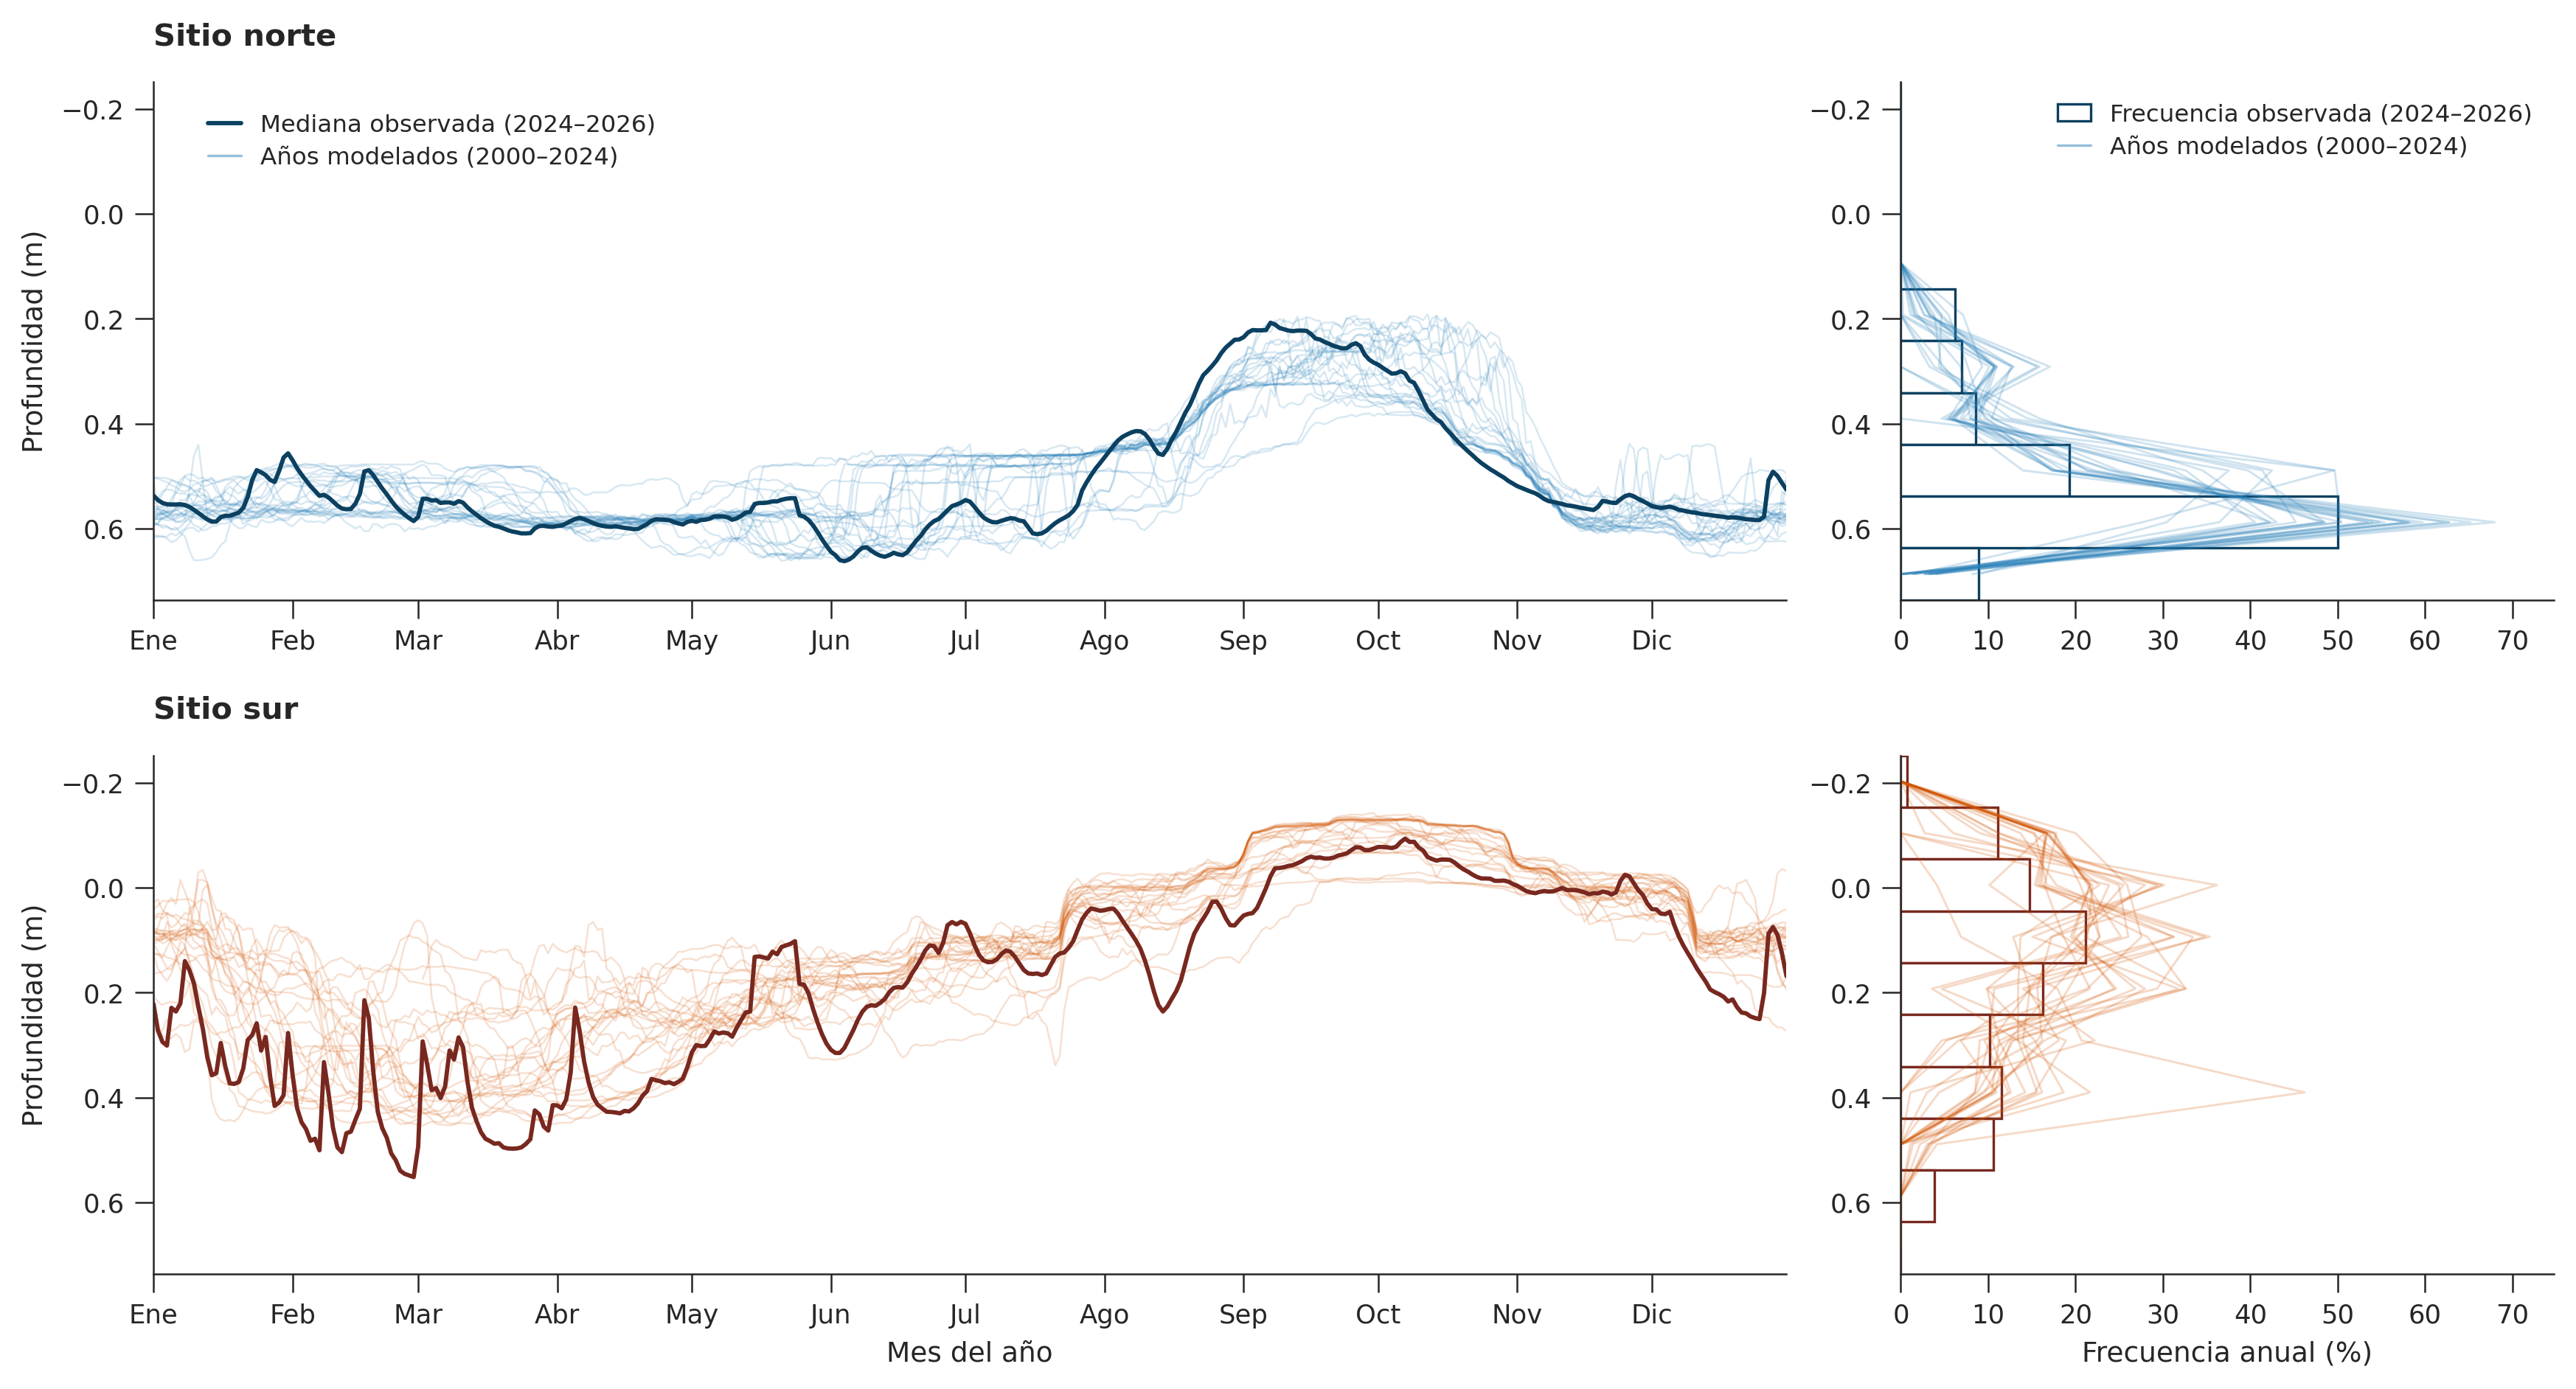

In [61]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set global styling for scientific publication
sns.set_theme(style="ticks")
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,
        "figure.titlesize": 11,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
    }
)

# -------------------------------------------------------------------------
# 1. Configuration & Color Palettes
# SDH1 (Blue family) | SDH2 (Vermilion family)
# -------------------------------------------------------------------------
SITE_COLORS = {
    "sdh1": {
        "observed": "#0b4060",
        "modeled": "#2980b9",
    },
    "sdh2": {
        "observed": "#78281f",
        "modeled": "#d35400",
    },
}

NUMBER_OF_BINS = 10


# -------------------------------------------------------------------------
# 2. Helper Functions
# -------------------------------------------------------------------------
def clean_annual_series(df: pd.DataFrame) -> pd.Series:
    """Drop NaN values and remove leap day (DOY 366) to standardize to 365 days."""
    s = df.iloc[:, 0].dropna()
    return s[s.index.dayofyear <= 365]


def compute_annual_cycle_stats(series: pd.Series) -> pd.DataFrame:
    """Calculate daily DOY summary statistics across years for observed series."""
    df_doy = pd.DataFrame({"depth": series, "doy": series.index.dayofyear})
    return (
        df_doy.groupby("doy")["depth"]
        .agg(
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            v_min="min",
            v_max="max",
        )
        .reindex(range(1, 366))
    )


def compute_annual_modeled_percentages(
    series: pd.Series, bin_edges: np.ndarray
) -> list:
    """Compute annual percentage distribution for each individual modeled year."""
    annual_percentages = []
    for _, year_group in series.groupby(series.index.year):
        valid_vals = year_group.dropna().values
        if len(valid_vals) > 30:
            counts, _ = np.histogram(valid_vals, bins=bin_edges)
            percentages = (counts / len(valid_vals)) * 100.0
            annual_percentages.append(percentages)
    return annual_percentages


# -------------------------------------------------------------------------
# 3. Data Preprocessing & Global Scale Definition
# -------------------------------------------------------------------------
series_mod_sdh1 = clean_annual_series(sdh1_modeled_2000_2024)
series_obs_sdh1 = clean_annual_series(sdh1_observed)
series_mod_sdh2 = clean_annual_series(sdh2_modeled_2000_2024)
series_obs_sdh2 = clean_annual_series(sdh2_observed)

# Unified depth limits across all sites and panels
all_depth_values = np.concatenate(
    [
        series_mod_sdh1.values,
        series_obs_sdh1.values,
        series_mod_sdh2.values,
        series_obs_sdh2.values,
    ]
)
depth_pad = (all_depth_values.max() - all_depth_values.min()) * 0.06
depth_min = all_depth_values.min() - depth_pad
depth_max = all_depth_values.max() + depth_pad

# Bin structure for horizontal frequency distributions
bin_edges = np.linspace(depth_min, depth_max, NUMBER_OF_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# Calendar month ticks for annual cycle DOY (non-leap year)
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]

# -------------------------------------------------------------------------
# 4. Figure Setup & Rendering
# -------------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 7),
    sharey=True,
    gridspec_kw={"width_ratios": [3.0, 1.2], "wspace": 0.1, "hspace": 0.3},
    dpi=300,
)

sites_config = [
    {
        "key": "sdh1",
        "name": "Sitio norte",
        "mod_series": series_mod_sdh1,
        "obs_series": series_obs_sdh1,
        "ax_cycle": axes[0, 0],
        "ax_dist": axes[0, 1],
        "row_idx": 0,
    },
    {
        "key": "sdh2",
        "name": "Sitio sur",
        "mod_series": series_mod_sdh2,
        "obs_series": series_obs_sdh2,
        "ax_cycle": axes[1, 0],
        "ax_dist": axes[1, 1],
        "row_idx": 1,
    },
]

max_percentage_observed = 0.0

for s in sites_config:
    k = s["key"]
    c_mod = SITE_COLORS[k]["modeled"]
    c_obs = SITE_COLORS[k]["observed"]
    ax_cycle = s["ax_cycle"]
    ax_dist = s["ax_dist"]

    # --- A. Annual Cycle (Left Panel) ---
    # 1. Faint individual modeled yearly trajectories (2000-2024)
    mod_df_doy = pd.DataFrame(
        {
            "depth": s["mod_series"],
            "doy": s["mod_series"].index.dayofyear,
            "year": s["mod_series"].index.year,
        }
    )

    for _, year_group in mod_df_doy.groupby("year"):
        if len(year_group) > 30:
            year_sorted = year_group.sort_values("doy")
            ax_cycle.plot(
                year_sorted["doy"],
                year_sorted["depth"],
                color=c_mod,
                alpha=0.18,
                linewidth=0.6,
            )

    # 2. Observed median trajectory (2024-2026)
    stats_obs = compute_annual_cycle_stats(s["obs_series"])
    ax_cycle.plot(
        stats_obs.index,
        stats_obs["median"],
        color=c_obs,
        linestyle="-",
        linewidth=1.4,
    )

    ax_cycle.set_title(s["name"], loc="left", fontweight="bold", pad=12)
    ax_cycle.set_ylabel("Profundidad (m)")
    ax_cycle.set_xlim(1, 365)
    ax_cycle.set_xticks(month_starts)
    ax_cycle.set_xticklabels(month_labels)

    if s["row_idx"] == 1:
        ax_cycle.set_xlabel("Mes del año")
    else:
        ax_cycle.set_xlabel("")

    # --- B. Frequency Distribution (Right Panel) ---
    # 1. Faint individual modeled annual frequency curves (2000-2024)
    mod_annual_pcts = compute_annual_modeled_percentages(
        s["mod_series"], bin_edges
    )
    for pcts in mod_annual_pcts:
        ax_dist.plot(
            pcts,
            bin_centers,
            color=c_mod,
            alpha=0.22,
            linewidth=0.7,
        )

    # 2. Observed frequency histogram bars (2024-2026)
    obs_vals = s["obs_series"].dropna().values
    counts_obs, _ = np.histogram(obs_vals, bins=bin_edges)
    obs_percentage = (counts_obs / len(obs_vals)) * 100.0

    ax_dist.barh(
        bin_centers,
        obs_percentage,
        height=bin_width,
        facecolor="white",
        edgecolor=c_obs,
        linewidth=0.8,
    )

    ax_dist.tick_params(labelleft=True)

    if s["row_idx"] == 1:
        ax_dist.set_xlabel("Frecuencia anual (%)")
    else:
        ax_dist.set_xlabel("")

    # Track maximum percentage for unified horizontal scaling
    highest_mod_pct = (
        max([p.max() for p in mod_annual_pcts]) if mod_annual_pcts else 0.0
    )
    local_max = max(obs_percentage.max(), highest_mod_pct)
    if local_max > max_percentage_observed:
        max_percentage_observed = local_max

    # Spine formatting
    sns.despine(ax=ax_cycle, top=True, right=True)
    sns.despine(ax=ax_dist, top=True, right=True)

# -------------------------------------------------------------------------
# 5. Global Scale Alignment & Inverted Y-Axis
# Invert Y-axis so groundwater depth increases downwards (depth_max at bottom)
# -------------------------------------------------------------------------
axes[0, 0].set_ylim(depth_max, depth_min)

# Standardize horizontal limits for frequency panels
freq_x_limit = max_percentage_observed * 1.10
axes[0, 1].set_xlim(0, freq_x_limit)
axes[1, 1].set_xlim(0, freq_x_limit)

# Color references for top site (SDH1) legends
c_mod_ref = SITE_COLORS["sdh1"]["modeled"]
c_obs_ref = SITE_COLORS["sdh1"]["observed"]

# --- Legend: Annual Cycle (axes[0, 0]) ---
cycle_legend_elements = [
    Line2D(
        [0],
        [0],
        color=c_obs_ref,
        linestyle="-",
        linewidth=1.4,
        label="Mediana observada (2024–2026)",
    ),
    Line2D(
        [0],
        [0],
        color=c_mod_ref,
        linestyle="-",
        linewidth=0.8,
        alpha=0.50,
        label="Años modelados (2000–2024)",
    ),
]

axes[0, 0].legend(
    handles=cycle_legend_elements,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=False,
    fontsize=7.8,
    handlelength=1.4,
    labelspacing=0.4,
)

# --- Legend: Annual Frequency (axes[0, 1]) ---
dist_legend_elements = [
    Patch(
        facecolor="white",
        edgecolor=c_obs_ref,
        linewidth=0.8,
        label="Frecuencia observada (2024–2026)",
    ),
    Line2D(
        [0],
        [0],
        color=c_mod_ref,
        linestyle="-",
        linewidth=0.8,
        alpha=0.50,
        label="Años modelados (2000–2024)",
    ),
]

axes[0, 1].legend(
    handles=dist_legend_elements,
    loc="upper right",
    frameon=False,
    fontsize=7.8,
    handlelength=1.4,
    labelspacing=0.4,
)

plt.show()

#### 3. Heatmaps de predicciones

Datos:
- Predicciones de los modelos entre 2000 y 2026

Pendientes:
- Unificar figuras en una
- Ver cómo asegurar consistencia de colores con figuras anteriores

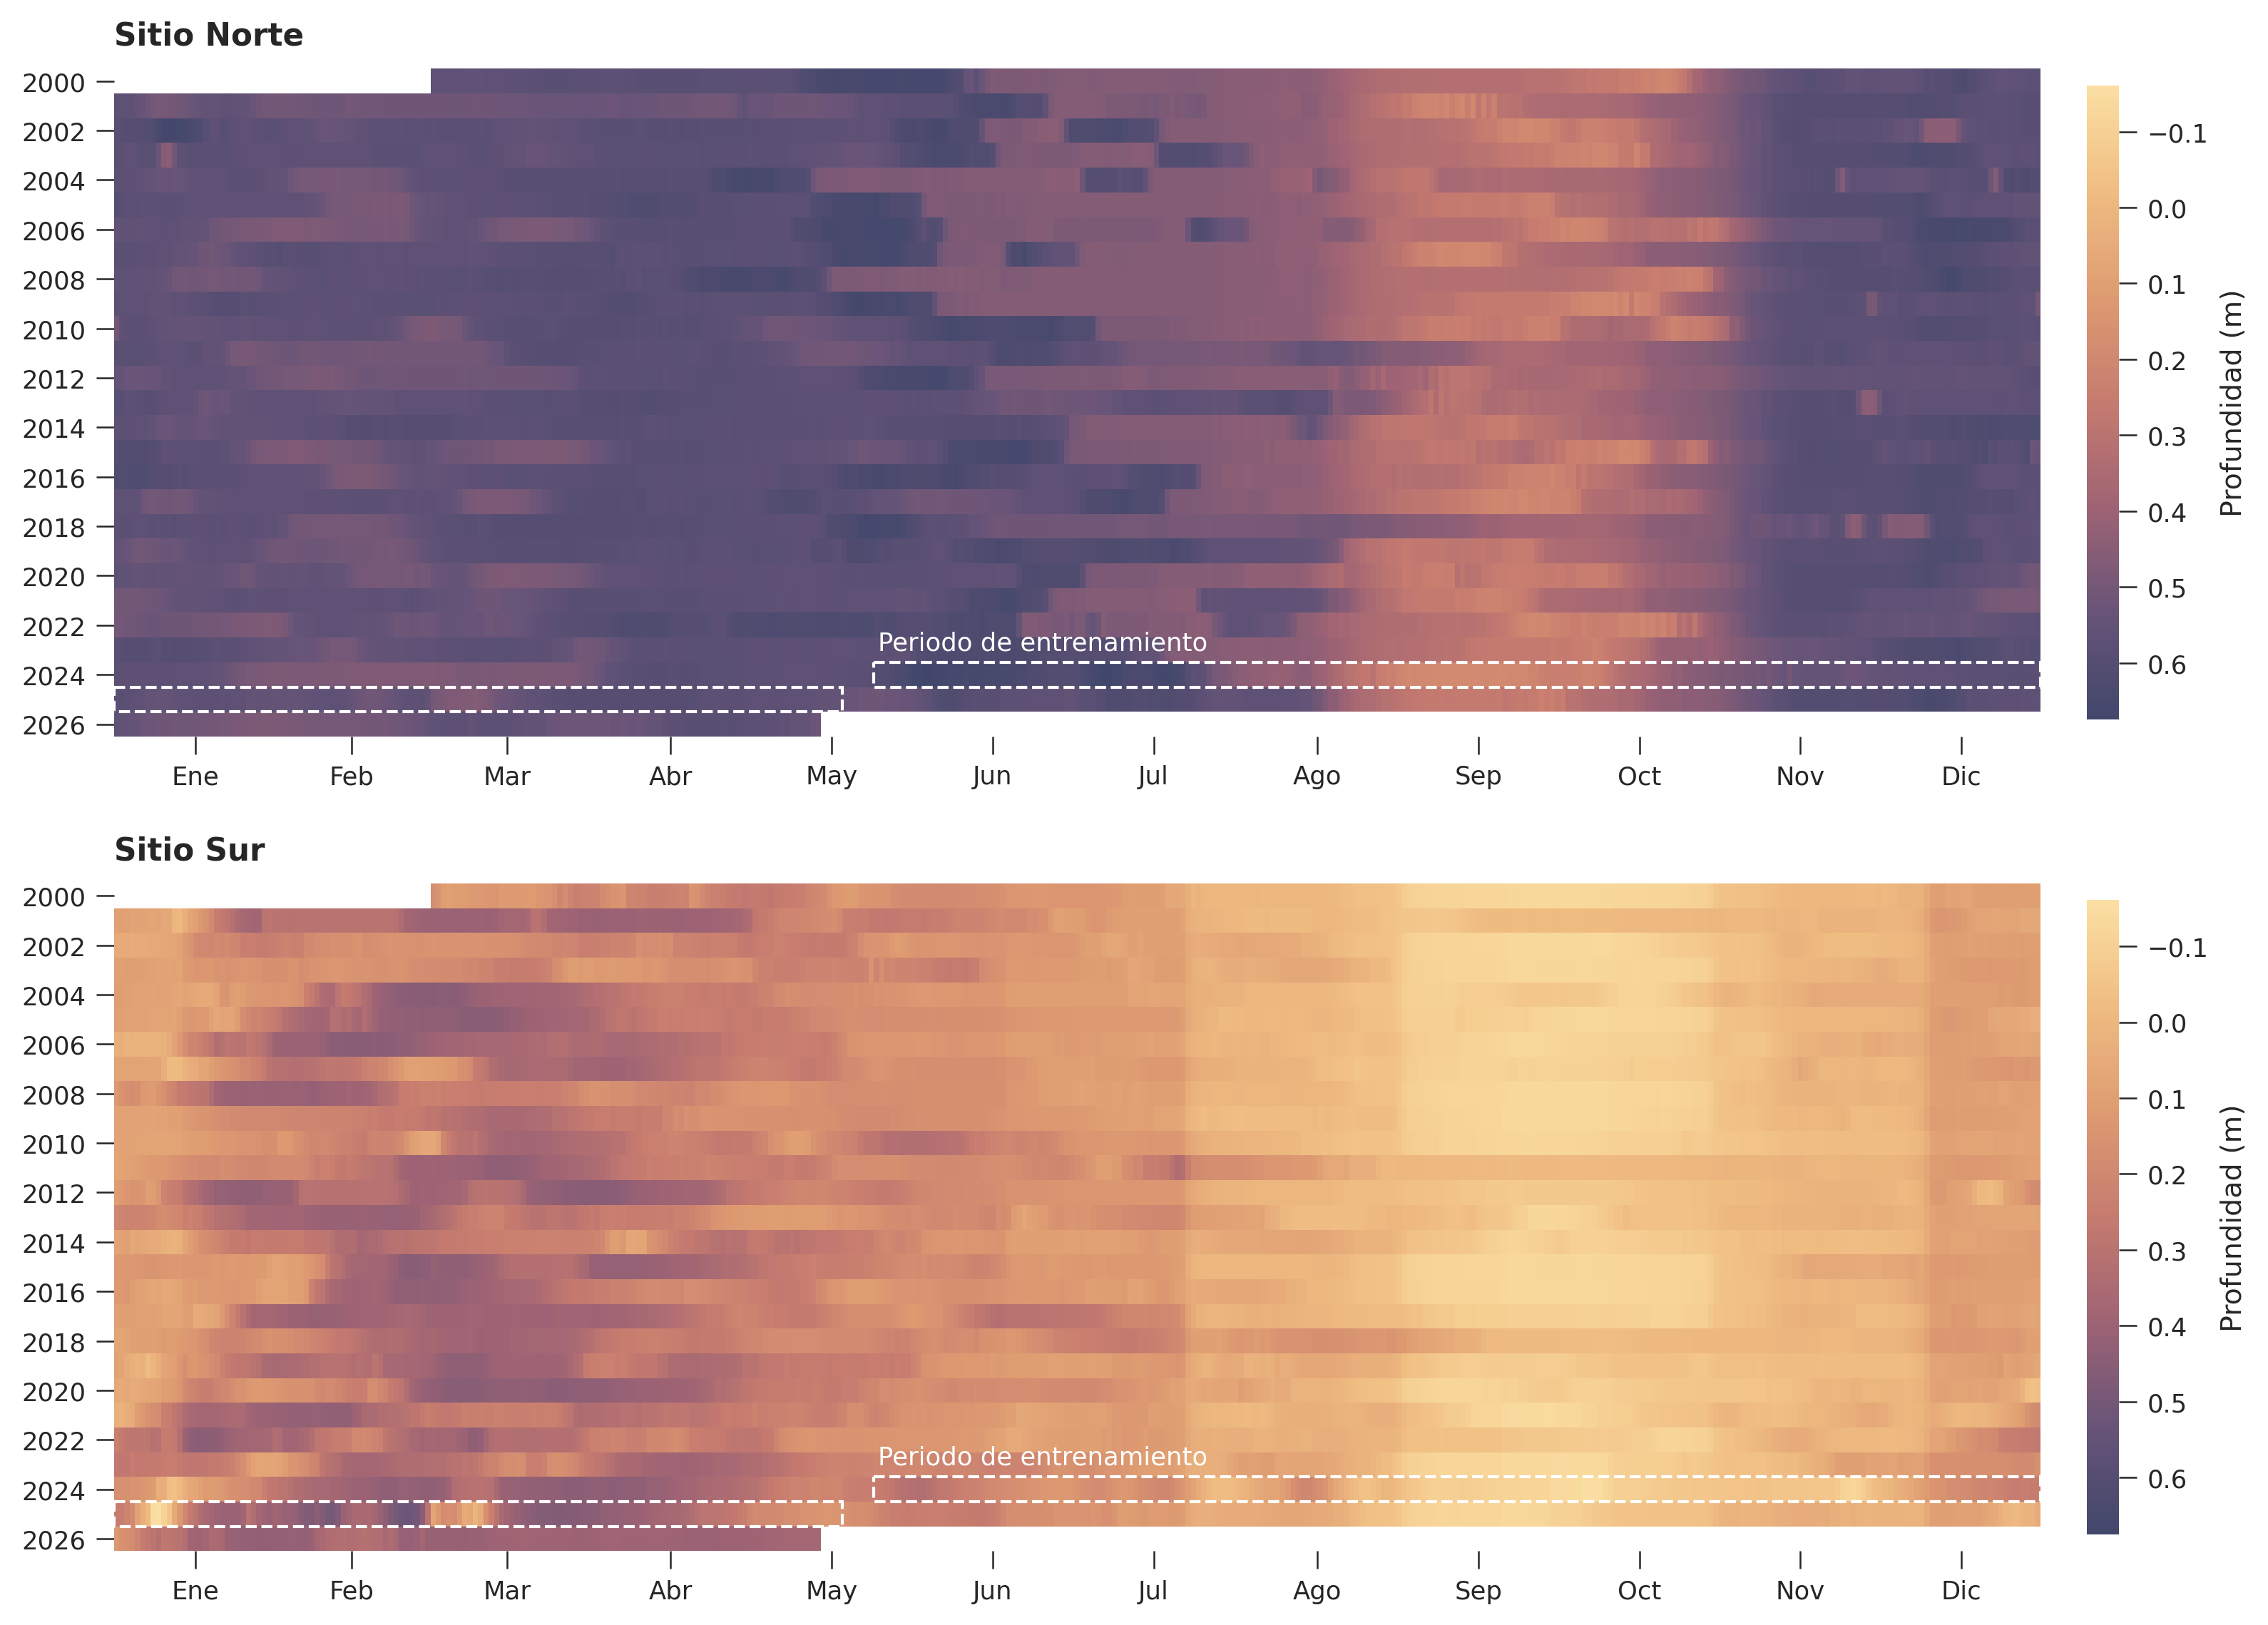

In [62]:
# Set global styling for scientific publication
sns.set_theme(style="ticks")
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10.5,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "figure.titlesize": 11,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
    }
)

# -------------------------------------------------------------------------
# 1. Configuration, Colormaps & Period Placeholders
# Consistent with previous figures: SDH1 (Blues) | SDH2 (Vermilion/Warm)
# -------------------------------------------------------------------------
cmap = load_cmap("Sunset", cmap_type="continuous", reverse=True)

SITE_COLORS = {
    "sdh1": {
        "title": "#0b4060",
        "cmap_colors": ["#f0f7fb", "#aed6f1", "#2980b9", "#0b4060"],
    },
    "sdh2": {
        "title": "#78281f",
        "cmap_colors": ["#fbf2eb", "#edbb99", "#d35400", "#78281f"],
    },
}

# Custom continuous colormaps matching site identities
cmap_sdh1 = LinearSegmentedColormap.from_list(
    "sdh1_depth", SITE_COLORS["sdh1"]["cmap_colors"]
)
cmap_sdh2 = LinearSegmentedColormap.from_list(
    "sdh2_depth", SITE_COLORS["sdh2"]["cmap_colors"]
)

# Placeholders for training and validation / testing periods
TRAIN_START = pd.Timestamp("2024-05-24")
TRAIN_END = pd.Timestamp("2025-05-18")
VAL_START = pd.Timestamp("2025-05-19")
VAL_END = pd.Timestamp("2026-05-14")

YEAR_START = 2000
YEAR_END = 2026
YEARS_RANGE = list(range(YEAR_START, YEAR_END + 1))
DAYS_RANGE = list(range(1, 366))


# -------------------------------------------------------------------------
# 2. Helper Functions
# -------------------------------------------------------------------------
def prepare_heatmap_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Extract DOY and year, drop leap days, and reindex to full year-day grid."""
    series = df.iloc[:, 0].dropna()
    filtered = series[series.index.dayofyear <= 365]

    df_grid = pd.DataFrame(
        {
            "year": filtered.index.year,
            "doy": filtered.index.dayofyear,
            "depth": filtered.values,
        }
    )

    pivot_table = df_grid.pivot(index="year", columns="doy", values="depth")
    return pivot_table.reindex(index=YEARS_RANGE, columns=DAYS_RANGE)


def highlight_period_cells(
    ax,
    years_list: list,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    edgecolor: str = "black",
    linestyle: str = "-",
    linewidth: float = 1,
):
    """Draw bounding boxes around a multi-year date range on the heatmap grid."""
    for yr in range(start_date.year, end_date.year + 1):
        if yr not in years_list:
            continue

        y_idx = years_list.index(yr)

        # Determine start DOY for the current year
        doy_start = start_date.dayofyear if yr == start_date.year else 1
        doy_start = min(doy_start, 365)

        # Determine end DOY for the current year
        doy_end = end_date.dayofyear if yr == end_date.year else 365
        doy_end = min(doy_end, 365)

        # Heatmap column index is (DOY - 1)
        x_start = doy_start - 1
        width = (doy_end - doy_start) + 1

        rect = patches.Rectangle(
            (x_start, y_idx),
            width,
            1.0,
            fill=False,
            edgecolor=edgecolor,
            linestyle=linestyle,
            linewidth=linewidth,
            clip_on=False,
            zorder=4,
        )
        ax.add_patch(rect)


# -------------------------------------------------------------------------
# 4. Data Preprocessing & Global Scale Definition
# -------------------------------------------------------------------------
heatmap_sdh1 = prepare_heatmap_matrix(sdh1_modeled)
heatmap_sdh2 = prepare_heatmap_matrix(sdh2_modeled)

# Shared depth limits to ensure consistent color scale across both sites
global_depth_min = min(heatmap_sdh1.min().min(), heatmap_sdh2.min().min())
global_depth_max = max(heatmap_sdh1.max().max(), heatmap_sdh2.max().max())

# Centered midpoints for month labels on the X-axis (DOY 1 to 365)
month_centers = [
    15.5,
    45.0,
    74.5,
    105.5,
    136.0,
    166.5,
    197.0,
    228.0,
    258.5,
    289.0,
    319.5,
    350.0,
]
month_names = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]

# Tick interval for Y-axis (every 2 years for optimal readability)
y_tick_indices = [
    i + 0.5 for i, yr in enumerate(YEARS_RANGE) if yr % 2 == 0 or yr == 2026
]
y_tick_labels = [
    str(yr) for yr in YEARS_RANGE if yr % 2 == 0 or yr == 2026
]

# -------------------------------------------------------------------------
# 5. Figure Setup & Rendering
# -------------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    dpi=300,
    gridspec_kw={"hspace": 0.22},
)

#cmap = 'viridis'
sites_config = [
    {
        "name": "Sitio Norte",
        "data": heatmap_sdh1,
        "ax": axes[0],
        "cmap": cmap,
        "row_idx": 0,
    },
    {
        "name": "Sitio Sur",
        "data": heatmap_sdh2,
        "ax": axes[1],
        "cmap": cmap,
        "row_idx": 1,
    },
]

for s in sites_config:
    ax = s["ax"]

    # Heatmap rendering with synchronized vmin and vmax
    ax = sns.heatmap(
        s["data"],
        ax=ax,
        cmap=s["cmap"],
        vmin=global_depth_min,
        vmax=global_depth_max,
        cbar=True,
        cbar_kws={
            "label": "Profundidad (m)",
            "pad": 0.02,
            "shrink": 0.95,
        },
        xticklabels=False,
        yticklabels=False,
    )

    ax.text(
        176,
        YEARS_RANGE.index(2024) - 0.8,
        "Periodo de entrenamiento",
        color="white",
        ha="center",
        va="center",
        fontsize=8.5,
    )
    # ax.text(
    #     100,
    #     YEARS_RANGE.index(2025) - 0.8,
    #     "Periodo de entrenamiento",
    #     color="white",
    #     ha="center",
    #     va="center",
    #     fontsize=7.5,
    # )
    # Highlight training period (solid outline) and validation period (dashed outline)
    highlight_period_cells(
        ax,
        YEARS_RANGE,
        TRAIN_START,
        TRAIN_END,
        edgecolor="white",
        linestyle="--",
        linewidth=1,
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.invert_yaxis()

    # X-axis formatting
    ax.set_xticks(month_centers)
    ax.set_xticklabels(month_names, rotation=0)

    # Y-axis formatting
    ax.set_yticks(y_tick_indices)
    ax.set_yticklabels(y_tick_labels, rotation=0)

    ax.set_title(s["name"], loc="left", fontweight="bold", pad=8)
    ax.set_ylabel("")

    if s["row_idx"] == 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("")


plt.show()